In [1]:
import os
import sys

import numpy as np
import pandas as pd

from pathlib import Path
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

import tiktoken

In [4]:
root_dir = Path("../../").resolve()
print(root_dir)

/home/hgkahng/Workspaces/soft-prompt


Load embeddings

In [5]:
emb_save_dir = root_dir / f"data/sst/embeddings/openai/text-embedding-3-small"
print(*os.listdir(emb_save_dir), sep='\n')

validation.features.npy
train.features.npy
train.labels.npy
test.features.npy
validation.labels.npy
test.labels.npy


In [6]:
X_train = np.load(emb_save_dir / "train.features.npy")
y_train = np.load(emb_save_dir / "train.labels.npy")
X_test  = np.load(emb_save_dir / "test.features.npy")
y_test  = np.load(emb_save_dir / "test.labels.npy")

Load text

In [8]:
ds = load_dataset("stanfordnlp/sst", trust_remote_code=True)

In [9]:
ds

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['sentence', 'label', 'tokens', 'tree'],
        num_rows: 2210
    })
})

In [10]:
train_data = ds['train'].to_pandas()
validation_data = ds['validation'].to_pandas()
test_data = ds['test'].to_pandas()

train_data.drop(['tokens', 'tree'], inplace=True, axis=1)
validation_data.drop(['tokens', 'tree'], inplace=True, axis=1)
test_data.drop(['tokens', 'tree'], inplace=True, axis=1)

In [11]:
encoding = tiktoken.encoding_for_model("gpt-4o")  # import tiktoken

In [12]:
train_data['num_tokens'] = [len(r) for r in encoding.encode_batch(train_data['sentence'])]
validation_data['num_tokens'] = [len(r) for r in encoding.encode_batch(validation_data['sentence'])]
test_data['num_tokens'] = [len(r) for r in encoding.encode_batch(test_data['sentence'])]

In [13]:
train_data['split'] = 'train'
validation_data['split'] = 'validation'
test_data['split'] = 'test'

data = pd.concat([train_data, validation_data, test_data], axis=0, ignore_index=True)

from IPython.display import display
display(data);

,sentence,label,num_tokens,split
0,The Rock is destined to be the 21st Century 's...,0.694440,45,train
1,The gorgeously elaborate continuation of `` Th...,0.833330,48,train
2,Singer\/composer Bryan Adams contributes a sle...,0.625000,41,train
3,You 'd think by now America would have had eno...,0.500000,23,train
4,Yet the act is still charming here .,0.722220,8,train
...,...,...,...,...
11850,An imaginative comedy\/thriller .,0.777780,7,test
11851,"( A ) rare , beautiful film .",0.916670,8,test
11852,( An ) hilarious romantic comedy .,0.888890,7,test
11853,Never ( sinks ) into exploitation .,0.625000,7,test


## Length

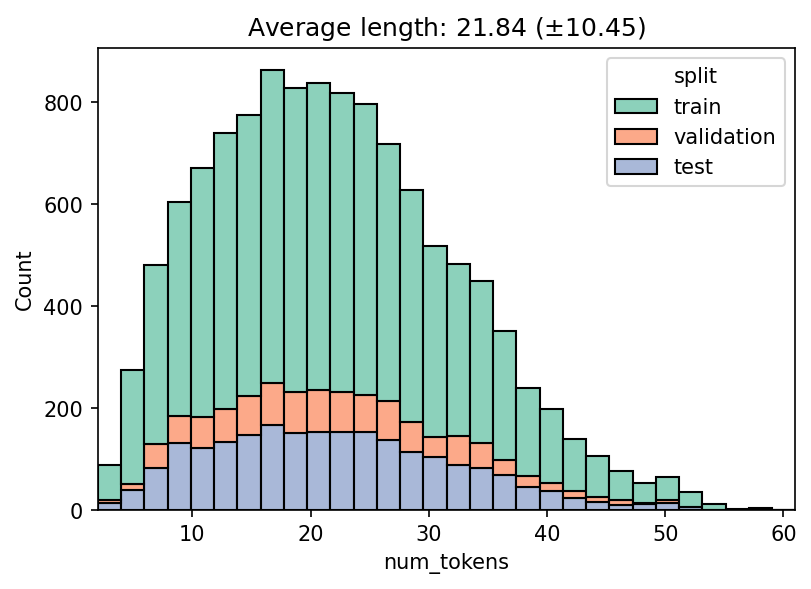

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
sns.histplot(data=data, x='num_tokens', hue='split', palette="Set2", alpha=.75, stat='count',
             edgecolor='k', shrink=1.0, bins=30, multiple='stack', ax=ax)
ax.set_title(
    f"Average length: {data['num_tokens'].mean():.2f} ($\pm${data['num_tokens'].std(ddof=1):.2f})"
)

lower_limit = data['num_tokens'].quantile(0.000)
upper_limit = data['num_tokens'].quantile(1.000)
ax.set_xlim(lower_limit, upper_limit)

plt.show(fig)

In [15]:
# for i, row in data.iterrows():
#     print(row['sentence'])
#     if i == 10:
#         break

## Label Distribution

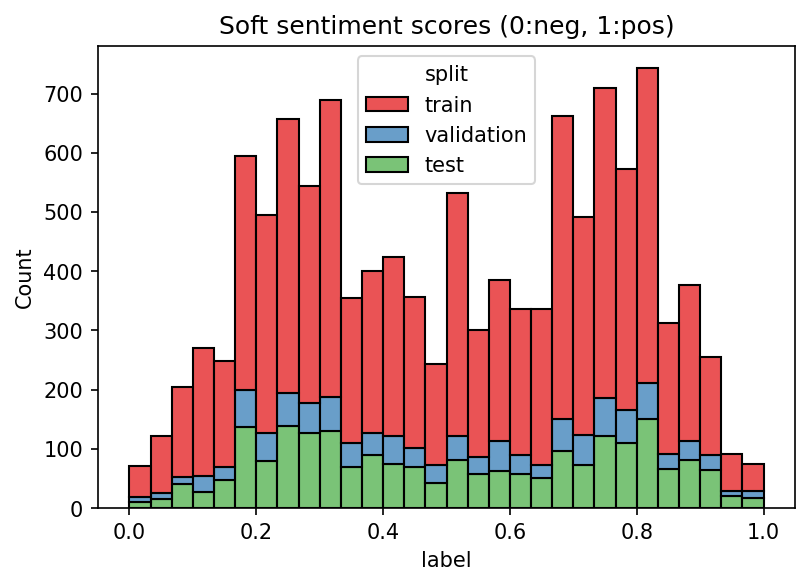

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=150)
sns.histplot(data=data, x='label', hue='split', palette="Set1", alpha=.75, stat='count',
             edgecolor='k', shrink=1.0, bins=30, multiple='stack', ax=ax)
ax.set_title(
    f"Soft sentiment scores (0:neg, 1:pos)"
)

plt.show(fig)

In [17]:
# for i, row in data.loc[data['label'] < 0.1].iterrows():
#     print(f"{row['label']:.3f}: {row['sentence']}")
#     if i == 100:
#         break

## Diversity Metrics

In [19]:
import sys
sys.path.insert(0, os.path.abspath("../../"))

from softprompt.metrics.diversity import (
    vocabulary_size,
    distinct_n,
    average_pairwise_similarity,
    average_pairwise_similarity_by_class,
    inter_sample_ngram_freq,
)

In [22]:
labels = y_train.copy()
texts = train_data['sentence'].to_list()
embeddings = X_train.copy()

assert len(texts) == labels.shape[0]
assert len(texts) == embeddings.shape[0]
print(labels.shape[0])

8544


In [23]:
vocab_size = vocabulary_size(texts)
print(f"Vocab: {vocab_size:>7,}")

Vocab:  18,267


In [24]:
distinct_2 = distinct_n(texts, n=2)
print(f"Distinct-2: {distinct_2:.4f}")

Distinct-2: 0.5625


In [25]:
%%time
inter_sim, intra_sim = average_pairwise_similarity_by_class(
    embeddings, labels
)
print(f"Inter-class APS: {inter_sim:.4f}\n",
      f"Intra-class APS: {intra_sim:.4f}")

Inter-class APS: 0.2531
 Intra-class APS: 0.2705
CPU times: user 10.7 s, sys: 2.18 s, total: 12.9 s
Wall time: 679 ms


In [26]:
%%time
avg_ps = average_pairwise_similarity(embeddings)
print(f"Avg Pairwise Similarity: {avg_ps:.4f}")

Avg Pairwise Similarity: 0.2534
CPU times: user 7.58 s, sys: 2.76 s, total: 10.3 s
Wall time: 575 ms


In [27]:
del texts, labels, embeddings

## Classification Performance

Training with hard labels

In [16]:
from sklearn.linear_model import LogisticRegressionCV

def evaluate_lg(X_train: np.ndarray,
                y_train: np.ndarray,
                X_test: np.ndarray,
                y_test: np.ndarray,
                subsample_size: int = 1000,
                bootstrap: bool = True,  # sampling with replacement
                n_trials: int = 50) -> dict[str, tuple[float, float]]:

    assert X_train.shape[0] == len(y_train)

    train_acc_array = np.empty(n_trials)
    test_acc_array = np.empty_like(train_acc_array)
    
    original_idx = np.arange(X_train.shape[0])  # [0, 1, ..., len(X_train)]

    for i in range(n_trials):
        
        # get indices to use for training
        rng = np.random.default_rng(42+i)
        if bootstrap:
            use_idx = rng.choice(original_idx, size=subsample_size, replace=True)
        else:
            shuffled_idx = rng.permutation(original_idx)
            use_idx = shuffled_idx[:subsample_size]

        # fit model
        lg = LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                  solver='lbfgs', max_iter=1000, n_jobs=8,
                                  random_state=42+i)
        lg.fit(X_train[use_idx], y_train[use_idx]);

        # evaluate
        train_acc_array[i] = lg.score(X_train[use_idx], y_train[use_idx])
        test_acc_array[i] = lg.score(X_test, y_test)

    return {
        'train_accuracy': (train_acc_array.mean(), train_acc_array.std(ddof=1)),
        'test_accuracy': (test_acc_array.mean(), test_acc_array.std(ddof=1)),
    }

In [17]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [21]:
size_to_acc = {}

ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 1.00)
subsample_sizes = [int(len(X_train) * r) for r in ratios]
for i, subsample_size in enumerate(subsample_sizes):

    print(f">> Sample size: {subsample_size:>6,} (r={ratios[i]:.2f})")

    eval_result = evaluate_lg(
        X_train,
        (y_train > 0.5).astype(int),
        X_test,
        (y_test > 0.5).astype(int),
        subsample_size=subsample_size,
        bootstrap=True,
        n_trials=50,
    )

    train_acc, test_acc = \
        eval_result['train_accuracy'], eval_result['test_accuracy']

    size_to_acc[subsample_size] = eval_result

    print("\t Train acc = {:.4f} ({:.4f})".format(*train_acc))
    print("\t  Test acc = {:.4f} ({:.4f})".format(*test_acc))

>> Sample size:     85 (r=0.01)
	 Train acc = 0.9908 (0.0160)
	  Test acc = 0.8352 (0.0210)
>> Sample size:    427 (r=0.05)
	 Train acc = 0.9440 (0.0336)
	  Test acc = 0.8730 (0.0094)
>> Sample size:    854 (r=0.10)
	 Train acc = 0.9325 (0.0272)
	  Test acc = 0.8801 (0.0055)
>> Sample size:  2,136 (r=0.25)
	 Train acc = 0.9337 (0.0231)
	  Test acc = 0.8829 (0.0070)
>> Sample size:  4,272 (r=0.50)
	 Train acc = 0.9479 (0.0221)
	  Test acc = 0.8752 (0.0118)
>> Sample size:  6,408 (r=0.75)
	 Train acc = 0.9557 (0.0135)
	  Test acc = 0.8692 (0.0121)
>> Sample size:  8,544 (r=1.00)
	 Train acc = 0.9468 (0.0113)
	  Test acc = 0.8730 (0.0102)
